# 03 - Transformation robustness + stage-share goodness of fit

Notebook 02 reported weighted marginals for LSM and CAP. This notebook checks how
robust the summary scalars are to scale choice and outliers, and -- the key
change from the earlier version -- judges each candidate fit by **how well it
reproduces the whole fibrosis stage-share vector (F0-F4)**, not just the F4
(cirrhosis) tail.

Why the reframe: the project now needs F1/F2/F3 accurate. The downstream sampler
consumes a lognormal's `(mean, sd)` and routes simulants by the 6/8/10/15 kPa
ladder, so the realised routing fractions are exactly the fitted lognormal's
stage shares. Getting the tail right at the expense of the body is the wrong trade.

Sections:
1. LSM and CAP on raw / sqrt / log scales (pooled trial band 65-80).
2. Back-transformed central estimates.
3. Outlier sensitivity (trim the top 1/5/10%).
4. **Stage-share goodness of fit**: moment-matched vs multi-cutoff-calibrated
   lognormal for LSM; Normal vs lognormal for CAP.


In [1]:
import warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import lsm_cap_fit as L
warnings.filterwarnings('ignore')

pool = pd.read_parquet(L.POOLED_PARQUET)
lsm = L.analysis_frame(pool, 'LSM')
cap = L.analysis_frame(pool, 'CAP')
# trial-band pooled sample (65-80 inclusive of the 80+ top-code)
def trial(frame):
    return frame[(frame['age_years'] >= 65) & (frame['age_years'] <= 80)].copy()
t_lsm, t_cap = trial(lsm), trial(cap)
yL, wL = t_lsm['LSM_KPA'].values, t_lsm['MEC_WT_POOL'].values
yC, wC = t_cap['CAP_DBM'].values, t_cap['MEC_WT_POOL'].values
print(f'trial-band 65-80 pooled: LSM n={len(t_lsm):,}, CAP n={len(t_cap):,}')


trial-band 65-80 pooled: LSM n=3,467, CAP n=3,467


## 1. Raw / sqrt / log scales

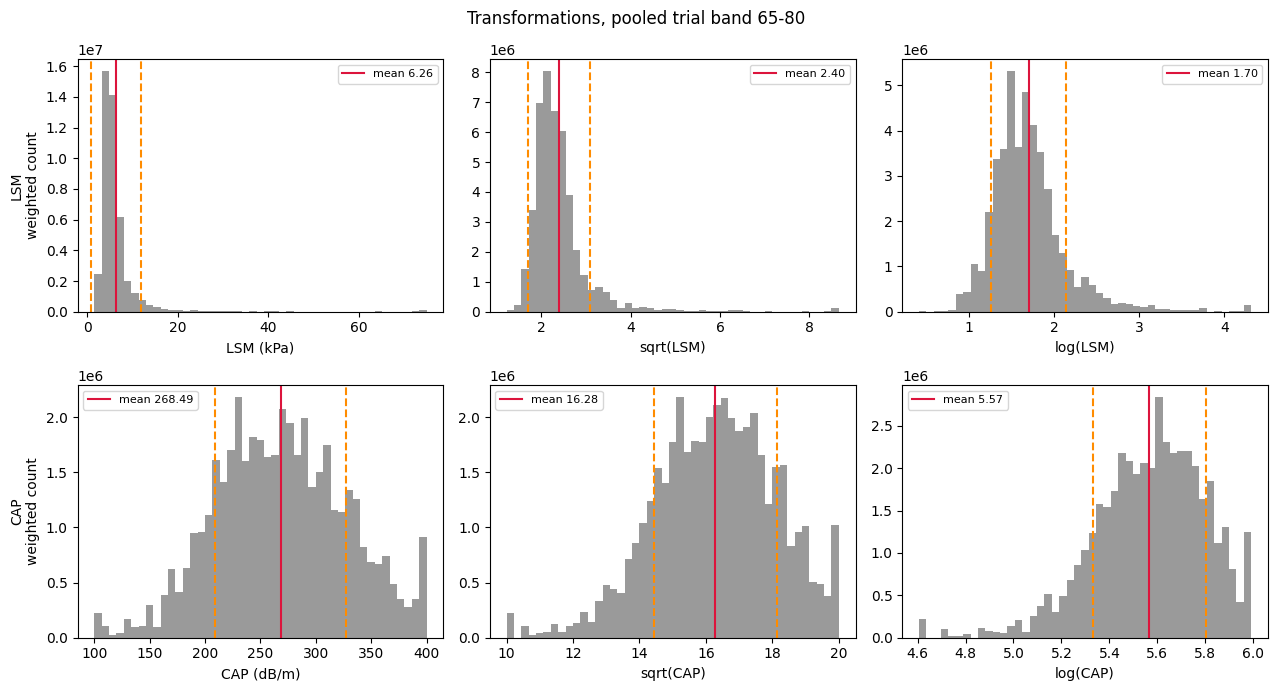

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for row, (vals0, w, name, unit) in enumerate([(yL, wL, 'LSM', 'kPa'), (yC, wC, 'CAP', 'dB/m')]):
    for ax, (label, vals, xlab) in zip(axes[row], [
        ('raw', vals0, f'{name} ({unit})'),
        ('sqrt', np.sqrt(vals0), f'sqrt({name})'),
        ('log', np.log(vals0), f'log({name})'),
    ]):
        ax.hist(vals, bins=45, weights=w, color='#888', alpha=0.85)
        m, s = L.w_mean(vals, w), L.w_sd(vals, w)
        ax.axvline(m, color='crimson', label=f'mean {m:.2f}')
        ax.axvline(m + s, color='darkorange', linestyle='--')
        ax.axvline(m - s, color='darkorange', linestyle='--')
        ax.set_xlabel(xlab); ax.legend(fontsize=8)
        if ax is axes[row][0]:
            ax.set_ylabel(f'{name}\nweighted count')
fig.suptitle('Transformations, pooled trial band 65-80')
fig.tight_layout(); plt.show()


## 2. Back-transformed central estimates

In [3]:
def back_transform_table(y, w):
    rows = [dict(scale='raw', mean=L.w_mean(y, w), SD=L.w_sd(y, w),
                 back_mean=L.w_mean(y, w), back_SD=L.w_sd(y, w))]
    ms, ss = L.w_mean(np.sqrt(y), w), L.w_sd(np.sqrt(y), w)
    rows.append(dict(scale='sqrt', mean=ms, SD=ss,
                     back_mean=ms**2 + ss**2, back_SD=np.sqrt(4 * ms**2 * ss**2)))
    mu, sg = L.w_log_mean(y, w), L.w_log_sd(y, w)
    bm, bs = L.lognorm_to_arith(mu, sg)
    rows.append(dict(scale='log', mean=mu, SD=sg, back_mean=bm, back_SD=bs))
    return pd.DataFrame(rows)

print('LSM (kPa):'); print(back_transform_table(yL, wL).round(3).to_string(index=False))
print(); print('CAP (dB/m):'); print(back_transform_table(yC, wC).round(3).to_string(index=False))


LSM (kPa):
scale  mean    SD  back_mean  back_SD
  raw 6.263 5.581      6.263    5.581
 sqrt 2.404 0.695      6.263    3.343
  log 1.697 0.444      6.025    2.814

CAP (dB/m):
scale    mean     SD  back_mean  back_SD
  raw 268.493 59.216    268.493   59.216
 sqrt  16.281  1.847    268.493   60.149
  log   5.567  0.236    268.894   64.274


## 3. Outlier sensitivity (top-% trim)

In [4]:
def trim_table(y, w):
    rows = []
    for top in [0, 1, 5, 10]:
        if top == 0:
            sy, sw, cut = y, w, float('inf')
        else:
            cut = L.w_quantile(y, w, 1 - top / 100)
            keep = y <= cut; sy, sw = y[keep], w[keep]
        rows.append(dict(top_pct=top, cutoff=cut, n=len(sy),
                         mean=L.w_mean(sy, sw), SD=L.w_sd(sy, sw)))
    return pd.DataFrame(rows)
print('LSM:'); print(trim_table(yL, wL).round(3).to_string(index=False))
print(); print('CAP:'); print(trim_table(yC, wC).round(3).to_string(index=False))


LSM:
 top_pct  cutoff    n  mean    SD
       0     inf 3467 6.263 5.581
       1  27.224 3431 5.815 2.899
       5  12.000 3298 5.387 1.835
      10   9.000 3113 5.101 1.411

CAP:
 top_pct  cutoff    n    mean     SD
       0     inf 3467 268.493 59.216
       1   400.0 3467 268.493 59.216
       5   367.0 3292 262.264 53.846
      10   348.0 3130 257.037 50.286


## 4. Stage-share goodness of fit (the reframed criterion)

For LSM, compare two lognormals on the pooled trial band:

- **moment-match** -- `(mu, sigma)` back-solved from the empirical arithmetic
  mean and SD (the project's historical approach), and
- **multi-cutoff calibrated** -- `(mu, sigma)` chosen to minimise the weighted
  squared error of the *stage shares*, prioritising F1/F2/F3 (notebook 04's method).

Then compare the implied F0-F4 shares against empirical. A single lognormal
cannot match a non-monotone stage profile exactly; the calibrated fit spends its
error where it is cheapest (F0, F4) and pins F1/F2/F3.


stage  empirical  moment_match  multicut_cal  mm_err_pp  cal_err_pp
   F0       65.9          62.8          67.0      -3.14        1.08
   F1       20.4          13.1          20.2      -7.34       -0.19
   F2        5.4           8.1           8.1       2.74        2.72
   F3        5.1           9.6           4.3       4.56       -0.82
   F4        3.2           6.4           0.4       3.18       -2.80

max |err| F1-F3:  moment-match 7.3 pp   vs  calibrated 2.7 pp


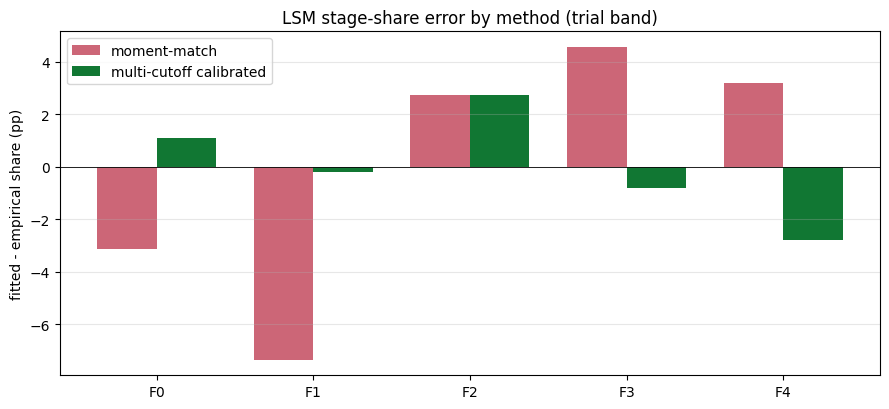

In [5]:
emp = L.empirical_stage_shares(yL, wL, L.LSM_CUTOFFS)
mu_mm, sg_mm = L.arith_to_lognorm(L.w_mean(yL, wL), L.w_sd(yL, wL))
mu_cal, sg_cal = L.fit_lognorm_multicut(yL, wL)
fit_mm = L.lognorm_stage_shares(mu_mm, sg_mm, L.LSM_CUTOFFS)
fit_cal = L.lognorm_stage_shares(mu_cal, sg_cal, L.LSM_CUTOFFS)

comp = pd.DataFrame({'stage': L.LSM_STAGES,
                     'empirical': emp, 'moment_match': fit_mm, 'multicut_cal': fit_cal})
comp['mm_err_pp'] = (comp['moment_match'] - comp['empirical']) * 100
comp['cal_err_pp'] = (comp['multicut_cal'] - comp['empirical']) * 100
print((comp.assign(empirical=(comp['empirical']*100).round(1),
                   moment_match=(comp['moment_match']*100).round(1),
                   multicut_cal=(comp['multicut_cal']*100).round(1))).round(2).to_string(index=False))
print(f"\nmax |err| F1-F3:  moment-match {np.abs(comp['mm_err_pp'][1:4]).max():.1f} pp"
      f"   vs  calibrated {np.abs(comp['cal_err_pp'][1:4]).max():.1f} pp")

x = np.arange(len(L.LSM_STAGES)); wbar = 0.38
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(x - wbar/2, comp['mm_err_pp'], wbar, color='#cc6677', label='moment-match')
ax.bar(x + wbar/2, comp['cal_err_pp'], wbar, color='#117733', label='multi-cutoff calibrated')
ax.axhline(0, color='k', lw=0.6); ax.set_xticks(x); ax.set_xticklabels(L.LSM_STAGES)
ax.set_ylabel('fitted - empirical share (pp)'); ax.set_title('LSM stage-share error by method (trial band)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y'); fig.tight_layout(); plt.show()


CAP weighted-KS by moment-matched family (smaller = better):
  normal     0.0269
  lognormal  0.0434
  beta       0.0341
-> default family: normal (KS 0.0269); best on this sample: normal


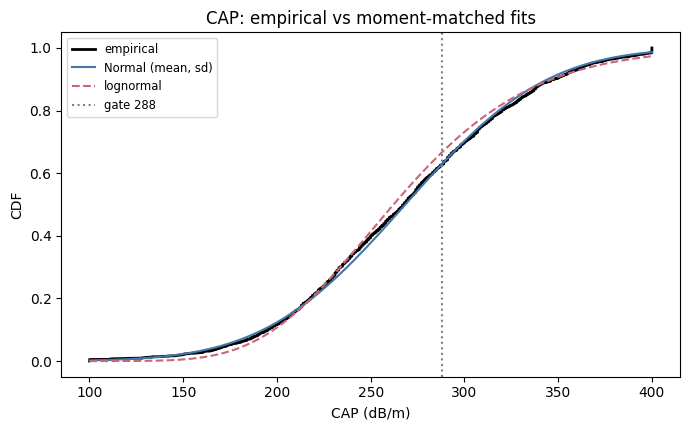

In [6]:
# CAP family choice: Normal vs lognormal vs scaled Beta by weighted KS.
ks = L.cap_family_ks(yC, wC)
print('CAP weighted-KS by moment-matched family (smaller = better):')
for fam, v in ks.items():
    print(f'  {fam:10} {v:.4f}')
best = min(ks, key=ks.get)
print(f'-> default family: normal (KS {ks["normal"]:.4f}); best on this sample: {best}')

o = np.argsort(yC); ys, ws = yC[o], wC[o]
emp_cdf = np.cumsum(ws) / ws.sum()
m, s = L.cap_moment_fit(yC, wC)
grid = np.linspace(ys.min(), ys.max(), 250)
fig, ax = plt.subplots(figsize=(7, 4.4))
ax.plot(ys, emp_cdf, color='black', lw=2, label='empirical')
ax.plot(grid, stats.norm.cdf(grid, m, s), color='#4477aa', label='Normal (mean, sd)')
mu, sg = L.arith_to_lognorm(m, s)
ax.plot(grid, stats.lognorm.cdf(grid, sg, scale=np.exp(mu)), color='#cc6677', ls='--', label='lognormal')
ax.axvline(L.CAP_STEATOSIS_GATE, color='gray', ls=':', label=f'gate {L.CAP_STEATOSIS_GATE:.0f}')
ax.set_xlabel('CAP (dB/m)'); ax.set_ylabel('CDF'); ax.set_title('CAP: empirical vs moment-matched fits')
ax.legend(fontsize='small'); fig.tight_layout(); plt.show()


## 5. Decision

- **Scale.** LSM: log-scale-implied mean tracks the raw mean and the top-5% trim
  moves it modestly -- a lognormal is a reasonable body model. CAP: symmetric and
  bounded, so a **Normal** moment match fits better than a lognormal (KS above).
- **Fit criterion.** The multi-cutoff-calibrated lognormal reduces the F1/F2/F3
  stage-share error versus the moment match, at the cost of a little F4 accuracy
  -- the intended trade, applied per (sex, age) in notebook 04.
- **CAP** is delivered as a moment-matched Normal per cell (no stage calibration).

Caveats carry over from notebook 02: halved pooled-cycle weights, complete-exam
selection, and age top-coded at 80.
